<a href="https://colab.research.google.com/github/nikhilkanse2596/LINEAR-REGRESSION-HANDSON/blob/main/Linear_Regression_house_price_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [415]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# data_set link = https://drive.google.com/file/d/18D1uOi4zEH15aKyMRv2MfD3n3IJUFd0T/view?usp=sharing

In [416]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/CSV FILES/House_Price_Data.csv")

In [417]:
df

,Property_ID,Area,Bedrooms,Bathrooms,Square_Feet,Parking,Furnishing_Status,Year_Built,Distance_to_CityCenter,Crime_Rate,Locality_Rating,House_Price
0,1,City Outskirts,3.0,3,1558,No,Unfurnished,NaN,11.40,38.95,NaN,174194
1,2,Industrial Zone,NaN,3,1785,Yes,Unfurnished,NaN,23.88,29.85,NaN,133069
2,3,Riverside,4.0,1,1442,Yes,Semi-Furnished,NaN,14.02,19.76,NaN,204347
3,4,Industrial Zone,3.0,4,1777,Yes,Semi-Furnished,NaN,17.63,55.76,NaN,224295
4,5,Uptown,2.0,2,632,Yes,Furnished,NaN,17.30,38.90,NaN,164406
...,...,...,...,...,...,...,...,...,...,...,...,...
8155,2081,Riverside,1.0,2,1621,Yes,Semi-Furnished,NaN,-12.73,57.14,NaN,124677
8156,6956,Suburb,3.0,3,2013,No,Furnished,2001.0,11.64,44.62,8.0,238917
8157,6488,City Outskirts,3.0,3,2151,Yes,Unfurnished,NaN,11.82,35.39,NaN,188446
8158,648,Suburb,3.0,1,2183,No,Furnished,NaN,8.31,38.61,NaN,252609


In [418]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8160 entries, 0 to 8159
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Property_ID             8160 non-null   int64  
 1   Area                    8160 non-null   object 
 2   Bedrooms                7762 non-null   float64
 3   Bathrooms               8160 non-null   int64  
 4   Square_Feet             8160 non-null   int64  
 5   Parking                 8160 non-null   object 
 6   Furnishing_Status       8160 non-null   object 
 7   Year_Built              1011 non-null   float64
 8   Distance_to_CityCenter  8160 non-null   float64
 9   Crime_Rate              8160 non-null   float64
 10  Locality_Rating         410 non-null    float64
 11  House_Price             8160 non-null   int64  
dtypes: float64(5), int64(4), object(3)
memory usage: 765.1+ KB


In [419]:
df.head()

,Property_ID,Area,Bedrooms,Bathrooms,Square_Feet,Parking,Furnishing_Status,Year_Built,Distance_to_CityCenter,Crime_Rate,Locality_Rating,House_Price
0,1,City Outskirts,3.0,3,1558,No,Unfurnished,NaN,11.40,38.95,NaN,174194
1,2,Industrial Zone,NaN,3,1785,Yes,Unfurnished,NaN,23.88,29.85,NaN,133069
2,3,Riverside,4.0,1,1442,Yes,Semi-Furnished,NaN,14.02,19.76,NaN,204347
3,4,Industrial Zone,3.0,4,1777,Yes,Semi-Furnished,NaN,17.63,55.76,NaN,224295
4,5,Uptown,2.0,2,632,Yes,Furnished,NaN,17.30,38.90,NaN,164406


In [420]:
df.describe()

,Property_ID,Bedrooms,Bathrooms,Square_Feet,Year_Built,Distance_to_CityCenter,Crime_Rate,Locality_Rating,House_Price
count,8160.00000,7762.000000,8160.000000,8160.000000,1011.000000,8160.000000,8160.000000,410.000000,8.160000e+03
mean,3995.63174,2.818732,2.385784,1819.669608,2000.787339,15.283775,49.872349,5.370732,1.965295e+05
std,2307.63745,1.039607,1.261377,563.037957,12.510403,8.216804,14.907067,2.834320,8.400908e+04
min,1.00000,1.000000,0.000000,-128.000000,1980.000000,-12.730000,-2.240000,1.000000,-5.895500e+04
25%,1997.75000,2.000000,2.000000,1466.750000,1990.000000,10.340000,39.910000,3.000000,1.437652e+05
50%,3990.50000,3.000000,2.000000,1810.000000,2001.000000,15.090000,49.835000,5.000000,1.958230e+05
75%,5996.25000,4.000000,3.000000,2156.000000,2012.000000,19.862500,60.150000,8.000000,2.456655e+05
max,8000.00000,5.000000,10.000000,11080.000000,2022.000000,100.000000,102.130000,10.000000,1.263530e+06


In [421]:
df.isnull().sum()

,0
Property_ID,0
Area,0
Bedrooms,398
Bathrooms,0
Square_Feet,0
Parking,0
Furnishing_Status,0
Year_Built,7149
Distance_to_CityCenter,0
Crime_Rate,0


In [422]:
df['Bedrooms'].median()

3.0

In [423]:
df = df.drop(columns=['Year_Built', 'Locality_Rating', 'Property_ID'])

In [424]:
df['Bedrooms'] = df['Bedrooms'].fillna(df['Bedrooms'].median())

In [425]:
df.isnull().sum()

,0
Area,0
Bedrooms,0
Bathrooms,0
Square_Feet,0
Parking,0
Furnishing_Status,0
Distance_to_CityCenter,0
Crime_Rate,0
House_Price,0


In [426]:
df.duplicated().sum()

np.int64(159)

In [427]:
df = df.drop_duplicates()

In [428]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8001 entries, 0 to 8034
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Area                    8001 non-null   object 
 1   Bedrooms                8001 non-null   float64
 2   Bathrooms               8001 non-null   int64  
 3   Square_Feet             8001 non-null   int64  
 4   Parking                 8001 non-null   object 
 5   Furnishing_Status       8001 non-null   object 
 6   Distance_to_CityCenter  8001 non-null   float64
 7   Crime_Rate              8001 non-null   float64
 8   House_Price             8001 non-null   int64  
dtypes: float64(3), int64(3), object(3)
memory usage: 625.1+ KB


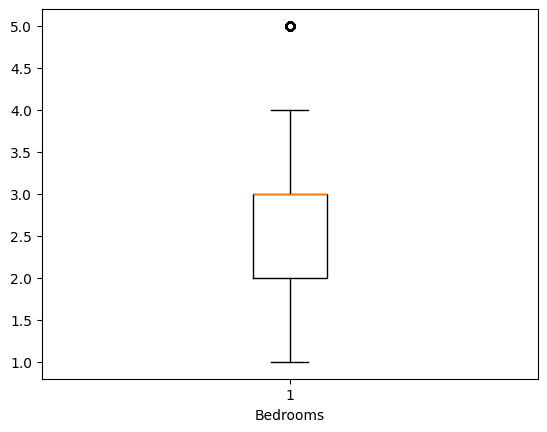

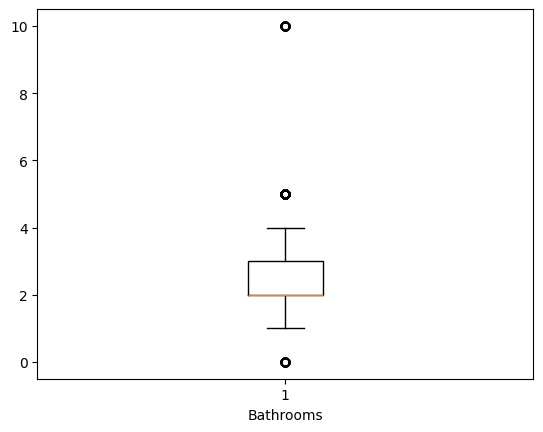

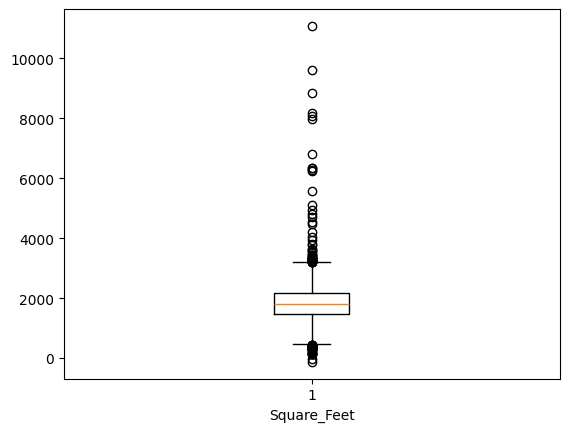

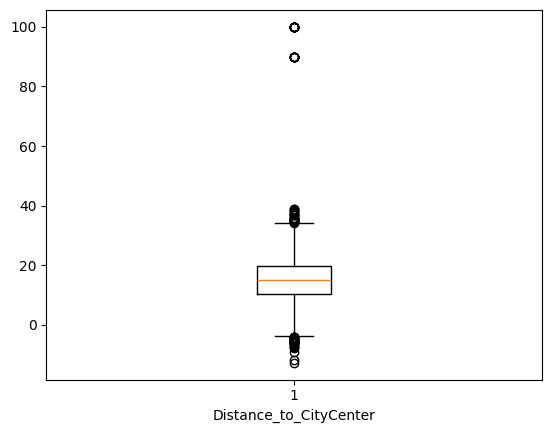

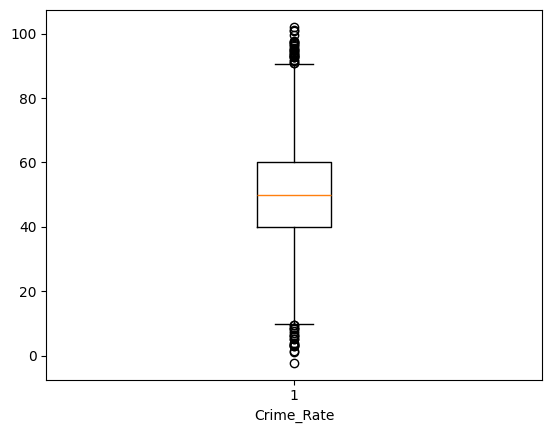

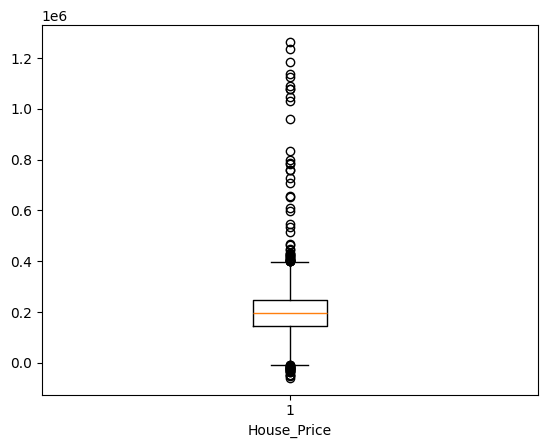

In [429]:
for i in df.columns:
    if df[i].dtype != 'object':
        plt.boxplot(df[i])
        plt.xlabel(i)
        plt.show()

# **REMOVING OUTLIERS**

In [430]:
# Apply IQR only to truly continuous predictors:
continuous_cols = ['Square_Feet', 'Distance_to_CityCenter', 'Crime_Rate']

for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    LB = Q1 - 1.5 * IQR
    UB = Q3 + 1.5 * IQR
    df = df[(df[col] >= LB) & (df[col] <= UB)]


df = df[(df['Distance_to_CityCenter'] >= 0) & (df['Crime_Rate'] >= 0) & (df['Square_Feet'] > 0)]

In [431]:
# Check the distribution first:
print(df['Bathrooms'].value_counts().sort_index())

# Filter only clearly erroneous bathroom counts
df = df[(df['Bathrooms'] >= 1) & (df['Bathrooms'] <= 5)]

Bathrooms
0       78
1     1554
2     3154
3     1856
4      794
5      210
10      71
Name: count, dtype: int64


In [432]:
df.shape

(7568, 9)

# **ENCODING**

In [433]:
# 1. Ordinal / Label encode Furnishing_Status
furnishing_order = {
    'Unfurnished': 0,
    'Semi-Furnished': 1,
    'Furnished': 2
}
df['Furnishing_Status'] = df['Furnishing_Status'].map(furnishing_order)

In [434]:
# 2. One-hot encode the nominal columns
df = pd.get_dummies(df, columns=['Area', 'Parking'], drop_first=True, dtype=int)

df.head()

,Bedrooms,Bathrooms,Square_Feet,Furnishing_Status,Distance_to_CityCenter,Crime_Rate,House_Price,Area_Downtown,Area_Hilltop,Area_Industrial Zone,Area_Riverside,Area_Suburb,Area_Uptown,Parking_Yes
0,3.0,3,1558,0,11.40,38.95,174194,0,0,0,0,0,0,0
1,3.0,3,1785,0,23.88,29.85,133069,0,0,1,0,0,0,1
2,4.0,1,1442,1,14.02,19.76,204347,0,0,0,1,0,0,1
3,3.0,4,1777,1,17.63,55.76,224295,0,0,1,0,0,0,1
4,2.0,2,632,2,17.30,38.90,164406,0,0,0,0,0,1,1


# **VIF**

In [435]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

In [436]:
X = df.drop(columns=['House_Price'])
X_const = sm.add_constant(X)

In [437]:
vif_data = pd.DataFrame()
vif_data['Feature'] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values,i) for i in range(len(X_const.columns))]
vif_data = vif_data[vif_data["Feature"] != 'const'].sort_values(by="VIF", ascending=False)
vif_data

,Feature,VIF
8,Area_Hilltop,1.758779
9,Area_Industrial Zone,1.733166
11,Area_Suburb,1.725238
7,Area_Downtown,1.720296
10,Area_Riverside,1.716826
12,Area_Uptown,1.708608
1,Bedrooms,1.002194
13,Parking_Yes,1.001927
6,Crime_Rate,1.001760
3,Square_Feet,1.001733


### all good to go

# **LETS BUILD MODEL**

In [438]:
df = df[df['House_Price'] > 0]

In [439]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['House_Price'])
y = df['House_Price']

x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=123)

In [440]:
from sklearn.linear_model import LinearRegression

In [441]:
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [442]:
y_pred = model.predict(x_test)

In [443]:
y_pred

array([157842.03730304, 207539.65317064, 254744.09273058, ...,
       109082.16940463, 152778.74158386, 204236.7873345 ])

In [444]:
y_test

,House_Price
1192,117153
4408,278652
1978,265178
2264,154175
7208,186062
...,...
2257,133805
161,183079
7304,156062
4779,179426


In [445]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [446]:
r2_score(y_test,y_pred)*100

46.900961751689564

In [447]:
# Predict on train and test
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

print(f"Train R²: {r2_score(y_train, y_train_pred):.4f}")
print(f"Test R²:  {r2_score(y_test, y_test_pred):.4f}")
print(f"Test MAE: ${mean_absolute_error(y_test, y_test_pred):,.2f}")
print(f"Test RMSE: ${mean_squared_error(y_test, y_test_pred)**0.5:,.2f}")

Train R²: 0.4676
Test R²:  0.4690
Test MAE: $42,208.83
Test RMSE: $53,296.94
